In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv('50_Startups.csv')
X = data.iloc[:,:-1].values
Y = data.iloc[:,-1].values

In [7]:
print(X)
print(Y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
encoder = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])],remainder='passthrough')
X = np.array(encoder.fit_transform(X))

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test = train_test_split(X,Y, test_size=0.4,random_state=1)

In [10]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [11]:
y_pred = regressor.predict(x_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)),1))

[[116799.25 105008.31]
 [ 93059.93  96479.51]
 [ 81206.79  78239.91]
 [ 74149.34  81229.06]
 [177209.96 191050.39]
 [169665.43 182901.99]
 [ 53107.35  35673.41]
 [102236.25 101004.64]
 [ 64137.18  49490.75]
 [ 98316.8   97483.56]
 [100858.52  97427.84]
 [ 88801.96  81005.76]
 [118831.27 111313.02]
 [ 79760.81  90708.19]
 [112919.3  122776.86]
 [ 76917.31  71498.49]
 [ 55751.98  14681.4 ]
 [110207.65 105733.54]
 [116140.55 110352.25]
 [129191.2  134307.35]]


In [12]:
col4 = X[:,3] + X[:,4] + X[:, 5]
X1 = np.column_stack((X[:,:3], col4))

In [13]:
x1_train,x1_test,y1_train,y1_test = train_test_split(X1, Y, test_size=0.4, random_state=1)


In [14]:
regressor2 = LinearRegression()
regressor2.fit(x1_train,y1_train)

LinearRegression()

In [20]:
y1_pred = regressor2.predict(x1_test)

[[0.0]
 [1.0]
 [1.0]
 [1.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [1.0]
 [1.0]
 [1.0]
 [0.0]
 [0.0]
 [1.0]
 [0.0]
 [1.0]
 [0.0]]


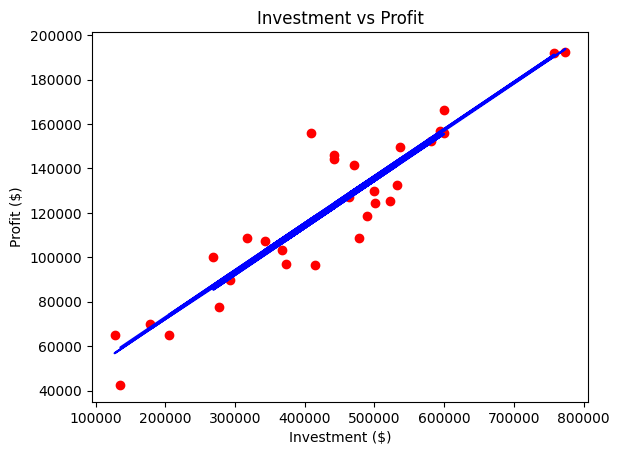

In [21]:
plt.scatter(x1_train[:,3:], y1_train, color='red')
plt.plot(x1_train[:,3:], regressor2.predict(x1_train), color='blue')
plt.title("Investment vs Profit")
plt.xlabel("Investment ($)")
plt.ylabel("Profit ($)")
plt.show()

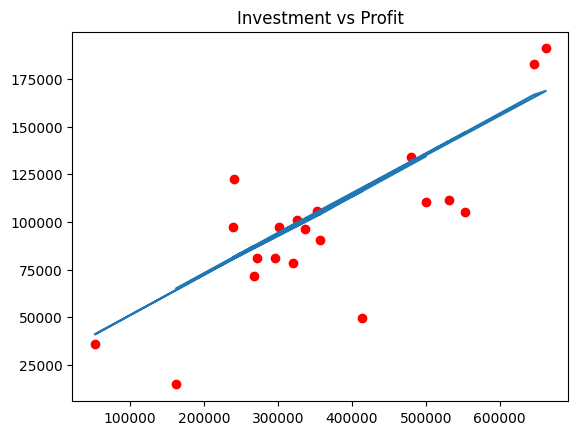

In [22]:
plt.scatter(x1_test[:,3:], y1_test, color='red')
plt.plot(x1_test[:,3:], regressor2.predict(x1_test))
plt.title("Investment vs Profit")
plt.show()